In [2]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd

In [4]:
atoms = 2000
dt = 5e-18
Temp = 15000
kb = 1.38e-23
NA = 6.022e23
MSI = 28.0855/NA #use cgs system
thermsteps = 801
thermvel = 100*(3*kb*Temp/(0.001*MSI))**0.5
velarr = np.array([2e5,3e5,6e5,1e6,2e6,3e6,6e6,1e7])
trajfilearr = []
logfilearr = []
namearr = []
numfiles = len(velarr)
folder="run8_13"
for i in range(numfiles):
    trajfilearr.append("{}/trajvel_{:.1e}.txt".format(folder,velarr[i]))
    logfilearr.append("{}/unforcedslumlogvel_{:.1e}.txt".format(folder,velarr[i]))
    namearr.append("v={:.1e}".format(velarr[i]))
trajfilearr = np.array(trajfilearr)
logfilearr = np.array(logfilearr)
namearr = np.array(namearr)
loglenarr = np.zeros(numfiles)
trajlenarr = np.zeros(numfiles)
def trajtoarr(filename, dt,atoms=1):
    timeflag =False
    atomflag=False
    count = 0
    timelist = []
    atomlist = []
    tempatomlist=[]
    tempatomlistx=[]
    tempatomlisty=[]
    atomlistx = []
    atomlisty = []
    with open(filename, 'r') as file:
        for line in file:
            if "ITEM" in line:
                if "ITEM: TIMESTEP" in line:
                    count += 1
                    timeflag = True
                    atomflag=False
                    atomlist.append(tempatomlist)
                    atomlistx.append(tempatomlistx)
                    atomlisty.append(tempatomlisty)

                    tempatomlist=[]
                    tempatomlistx=[]
                    tempatomlisty=[]

                elif "ITEM: ATOMS" in line:
                    atomflag = True
                    timeflag=False
                else:
                    timeflag = False
                    atomflag = False
            if timeflag and ("ITEM" not in line):
                timelist.append(float(line.strip()))
            if atomflag and ("ITEM" not in line):
                tempatomlist.append(float(line.strip().split(" ")[-1]))

                count += 1
    atomlist.append(tempatomlist)

    atomlist.pop(0)
    timearr = np.array(timelist)
    atomarr = np.array(atomlist)
    timearr *= dt
    return atomarr,timearr
def logtoarr(filename):
    startlogstr = "   Step          Time           Temp         c_tempH        c_tempSi        TotEng         PotEng         KinEng         Press     "
    endlogstr = "Loop time of "
    templist=[]
    dataflag=False
    with open(filename, 'r') as file:
        for line in file:
            if dataflag:
                dataline = list(filter(None, line.split(" ")))
                dataline[-1] = dataline[-1][:-1]
                dataline = list(filter(None, dataline))
                templist.append(dataline)
            if startlogstr in line:
                dataflag=True
                templist=[]
            if endlogstr in line:
                dataflag=False

    templist.pop()
    templist.pop()
    templist.pop()
    # print(templist)
    return np.array(templist,dtype=np.float64)

minloglength = int(60000/10+2)
mintrajlength = int(60000/10+2)
# for i in range(len(logfilearr)):
#     tempshape = np.shape(logtoarr(logfilearr[i]))
#     loglenarr[i] = tempshape[0]
#     if tempshape[0] > minloglength:
#         minloglength=tempshape[0]
#     tempforce,temptime = trajtoarr(trajfilearr[i],dt,atoms=atoms)
#     tempshape = np.shape(tempforce)
#     trajlenarr[i] = tempshape[0]
#     if tempshape[0] > mintrajlength:
#         mintrajlength=tempshape[0]
loglenarr = loglenarr.astype(int)
trajlenarr = trajlenarr.astype(int)

htemparr = np.zeros((numfiles,minloglength))
stemparr = np.zeros((numfiles,minloglength))
tengarr = np.zeros((numfiles,minloglength))
fzarr = np.zeros((numfiles,mintrajlength,atoms))
logtimelist = []
trajtimelist = []
for i in range(numfiles):
    print(i)
    datai = logtoarr(logfilearr[i])
    loglenarr[i] = np.shape(datai)[0]
    htemparr[i,:loglenarr[i]] = datai[:,3]
    stemparr[i,:loglenarr[i]] = datai[:,4]
    tengarr[i,:loglenarr[i]] = datai[:,5]
    logtimelist.append(datai[:,1])
    dt = (datai[1,1]-datai[0,1])/10
    tempfarr,temptimearr = trajtoarr(trajfilearr[i],dt,atoms=atoms)
    trajlenarr[i] = np.shape(tempfarr)[0]
    fzarr[i,:trajlenarr[i],:] = tempfarr
    trajtimelist.append(temptimearr)




0


FileNotFoundError: [Errno 2] No such file or directory: np.str_('run8_13/unforcedslumlogvel_2.0e+05.txt')

# Plot temp and energy over time

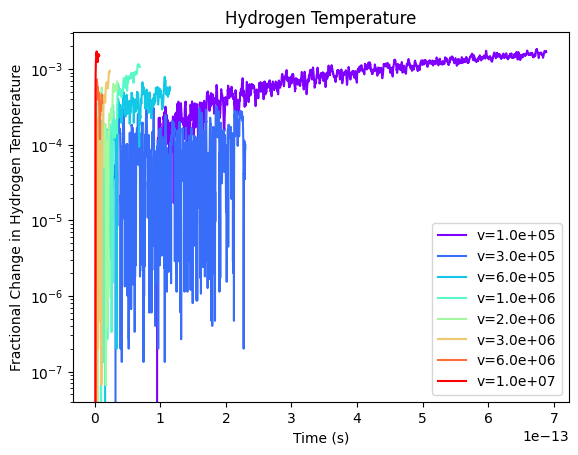

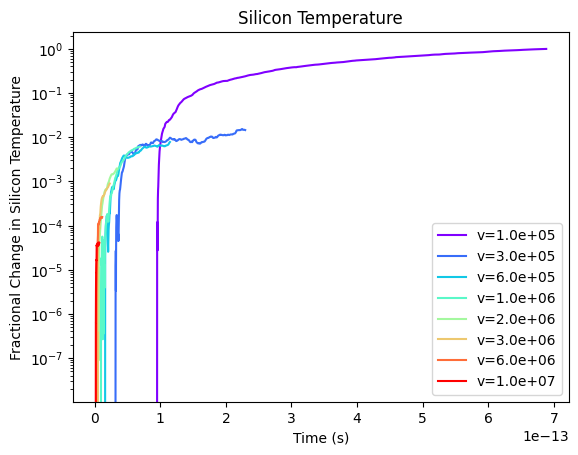

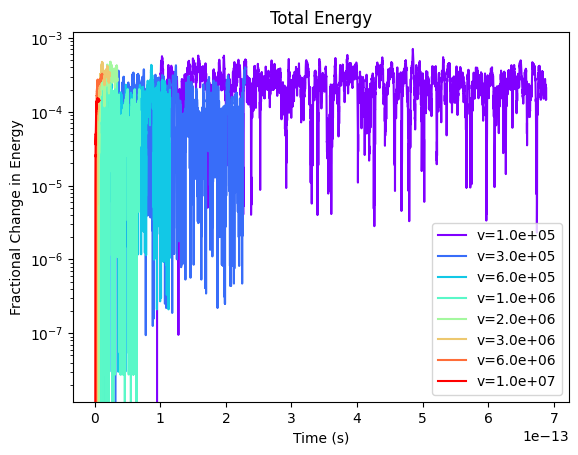

In [6]:
from matplotlib import cm
colors = cm.rainbow(np.linspace(0, 1, numfiles))

plt.figure()
plt.title("Hydrogen Temperature")
for i in range(numfiles):
    plt.plot(logtimelist[i],np.abs(htemparr[i,:loglenarr[i]]/htemparr[i,0]-1),color=colors[i],label=namearr[i])
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Fractional Change in Hydrogen Temperature")
plt.yscale("log")
plt.show()
plt.figure()
plt.title("Silicon Temperature")
for i in range(numfiles):
    plt.plot(logtimelist[i],np.abs(stemparr[i,:loglenarr[i]]/stemparr[i,0]-1),color=colors[i],label=namearr[i])
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Fractional Change in Silicon Temperature")
plt.yscale("log")
plt.show()
plt.title("Total Energy")
plt.yscale("log")

for i in range(numfiles):
    plt.plot(logtimelist[i],np.abs(tengarr[i,:loglenarr[i]]/tengarr[i,0]-1),color=colors[i],label=namearr[i])
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Fractional Change in Energy")
plt.show()

5801
5801
5801
5801
5801
5801
5801
5801
94596.56125385001


C:\Users\shaoq\AppData\Local\Temp\ipykernel_20204\1614580289.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


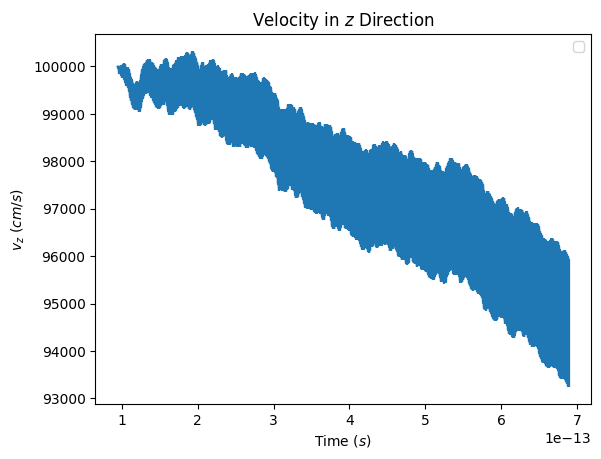

295611.54025


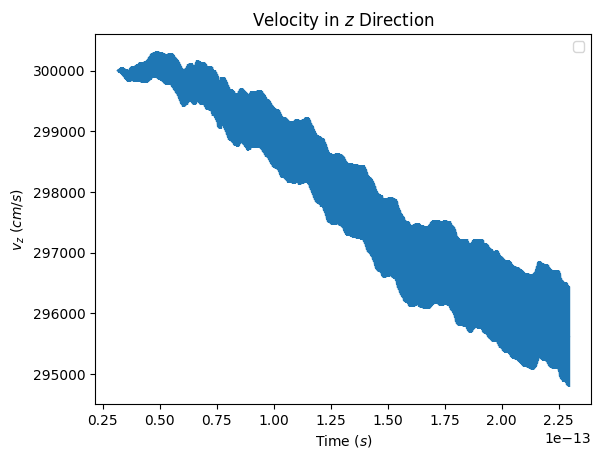

596079.35


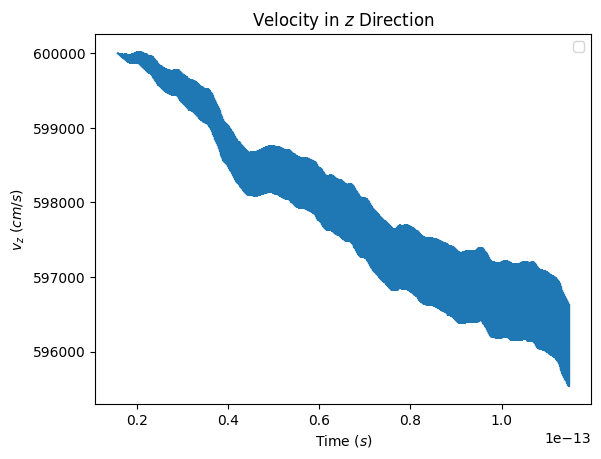

996322.4835


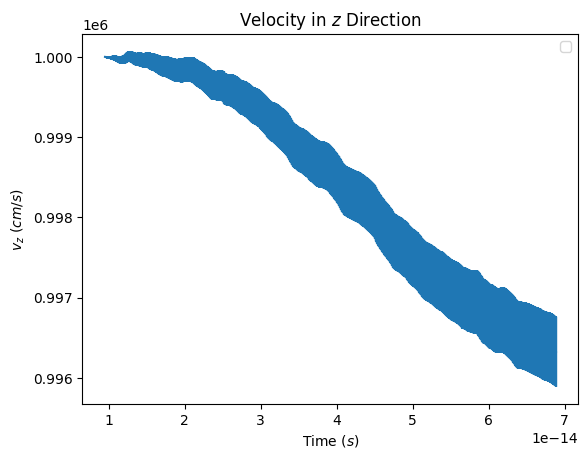

1997912.545


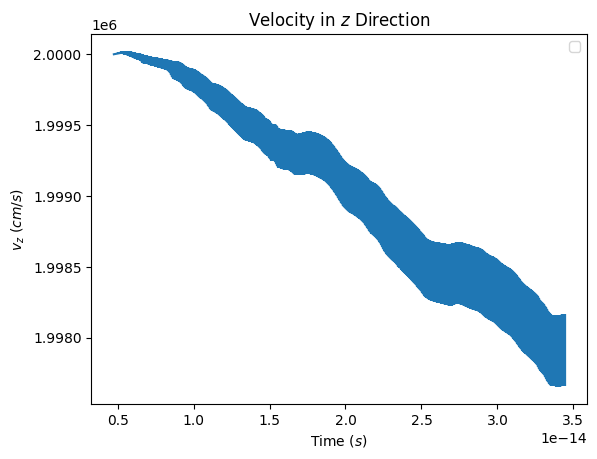

2998605.49


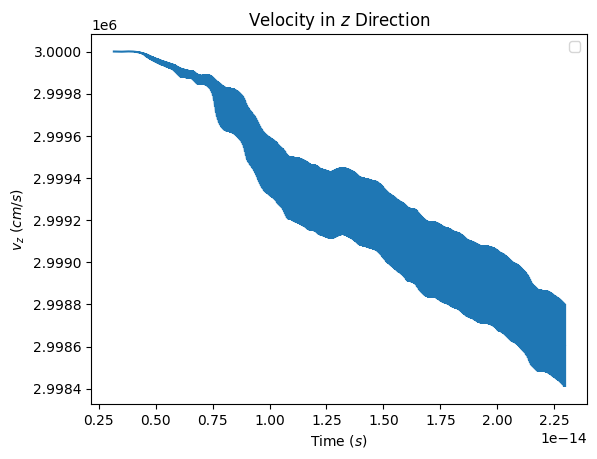

5999518.745


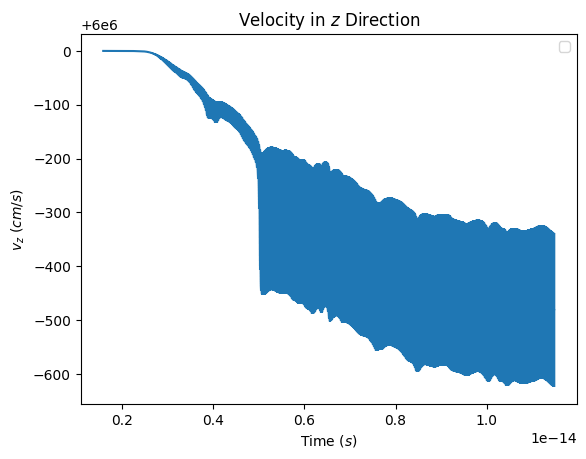

9999796.325


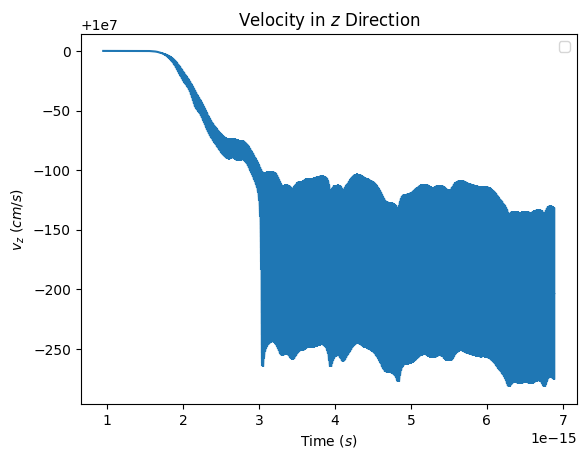

In [7]:
extractedv = np.zeros((numfiles,mintrajlength,2))
for i in range(numfiles):
    print(trajlenarr[i])

    for j in range(trajlenarr[i]):
        extractedv[i,j,0] = np.mean(fzarr[i,j,:])
        extractedv[i,j,1] = np.std(fzarr[i,j,:])/(atoms**0.5)


for i in range(numfiles):
    plt.figure()
    plt.errorbar(trajtimelist[i][thermsteps:], extractedv[i,thermsteps:trajlenarr[i],0],yerr=extractedv[i,thermsteps:trajlenarr[i],1])
    print(extractedv[i,trajlenarr[i]-1,0])
    plt.title(r"Velocity in $z$ Direction")
    plt.ylabel(r"$v_z$ ($cm/s$)")
    plt.xlabel(r"Time ($s$)")
    plt.legend()
    plt.show()

# Best Fit Accelerations

<>:30: SyntaxWarning: invalid escape sequence '\p'
<>:30: SyntaxWarning: invalid escape sequence '\p'
C:\Users\shaoq\AppData\Local\Temp\ipykernel_20204\1503248337.py:30: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(trajtimelist[i][skip:endi],yfit[skip:endi],label="fit slope = {:.1e}$\pm$ {:.1e}".format(bestfits[i,0],bestfits[i,3]))


i = 0,j=5800
101351.21702457171
-9196886450438456.0
99998.04810566429


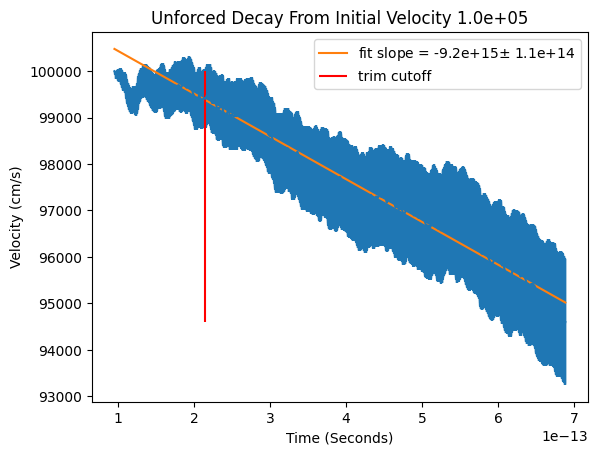

Reduced chi^2 = 6.857007518008861
i = 1,j=5800
301556.4327921387
-2.707441509816537e+16
300000.4444056643


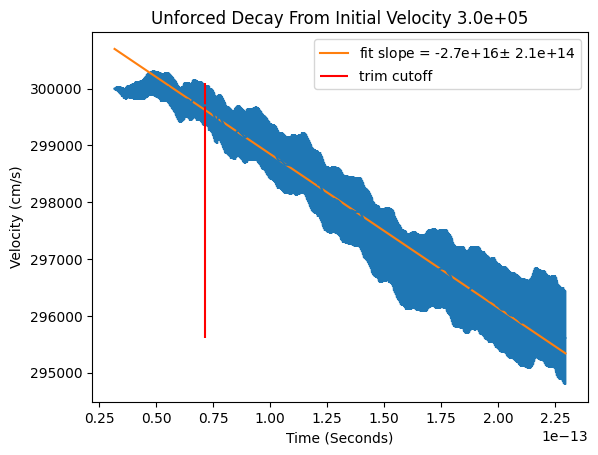

Reduced chi^2 = 57.20877725770819
i = 2,j=5800
600161.1811317826
-3.50956669541873e+16
599999.6894056642


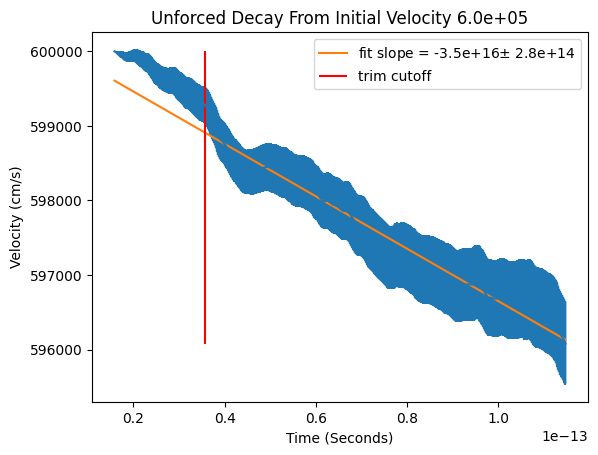

Reduced chi^2 = 129.80185004360746
i = 3,j=5800
1001636.9718852263
-8.006301451986773e+16
1000000.6554056642


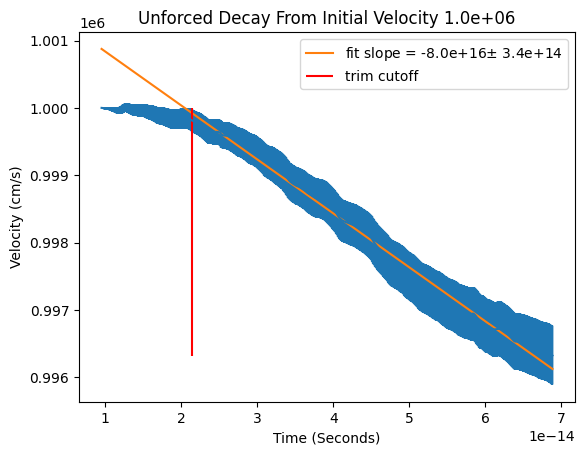

Reduced chi^2 = 1292.150471005365
i = 4,j=5800
2000588.4807399982
-7.760977839868811e+16
2000000.7964056642


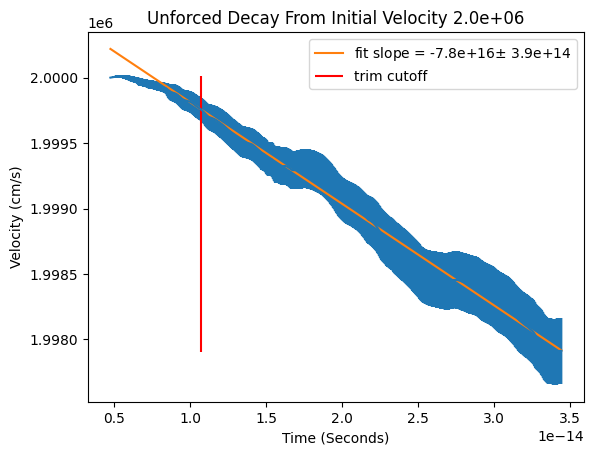

Reduced chi^2 = 730.7236873737962
i = 5,j=5800
3000403.943481894
-8.077622758903184e+16
3000000.631405664


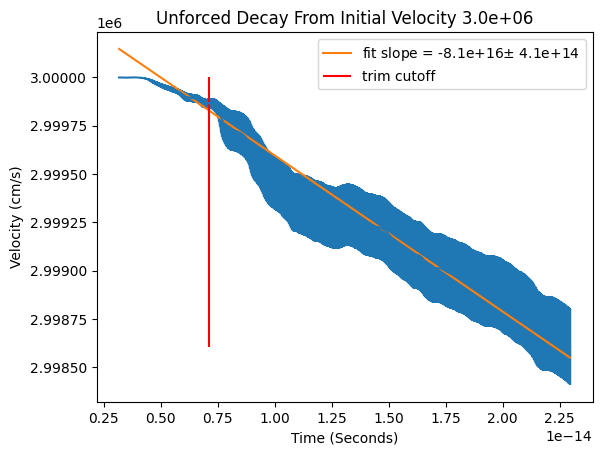

Reduced chi^2 = 95084.5678930782
i = 6,j=5800
6000171.4622990545
-6.786676118453525e+16
6000000.646405664


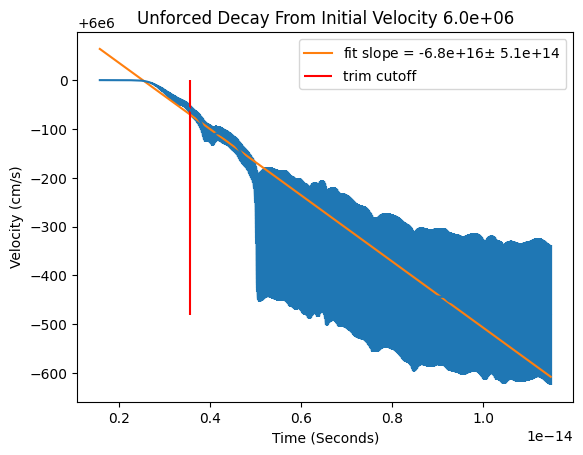

C:\Users\shaoq\AppData\Local\Temp\ipykernel_20204\1503248337.py:37: RuntimeWarning: divide by zero encountered in divide
  chisqr = sum((extractedv[i,skip:endi,0]-linearFunc(trajtimelist[i][skip:endi],slope,inter))**2/extractedv[i,skip:endi,1]**2)


Reduced chi^2 = inf
i = 7,j=5800
10000042.568013275
-4.5074084207523896e+16
10000000.646405665


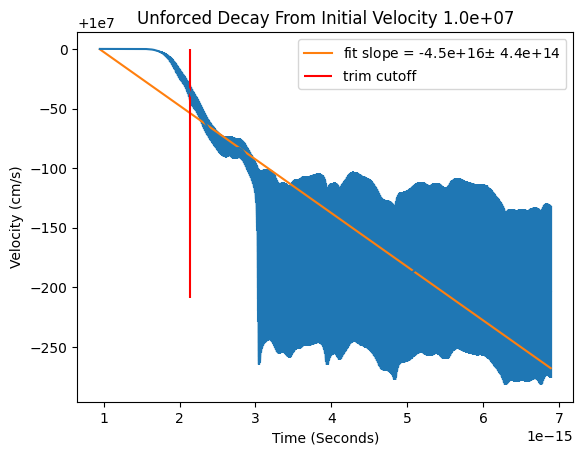

Reduced chi^2 = inf


In [17]:
from scipy.optimize import curve_fit
def linearFunc(x,m,b):
    return b+m*x
skip = int(8000/10+1)
bestfits = np.zeros((numfiles,5))
dropj = [[],[]]
slopguessarr=[0,-5.444195500000009e+18]
intguessarr = [1e4,1223405]
trim = 0.2
for i in range(numfiles):
    endi =trajlenarr[i]
    trimi = skip+int(0.2*(endi-skip))
    # slopguess=slopguessarr[i]
    # intguess = intguessarr[i]
    slopguess = -5.444195500000009e+18
    intguess = 1223405
    fit,cov = curve_fit(linearFunc,trajtimelist[i][trimi:endi],extractedv[i,trimi:endi,0],sigma=extractedv[i,trimi:endi,1],p0=[slopguess,intguess],absolute_sigma=True)
    inter = fit[1]
    slope = fit[0]
    bestfits[i,:2] = fit
    print("i = {},j={}".format(i,j))
    print(inter)
    print(slope)
    print(extractedv[i,skip,0]-dt*slopguess)
    d_inter = np.sqrt(cov[1][1])
    d_slope = np.sqrt(cov[0][0])
    bestfits[i,2:4] = [d_inter,d_slope]
    yfit = inter+ slope*trajtimelist[i]
    plt.errorbar(trajtimelist[i][skip:endi], extractedv[i,skip:endi,0],yerr=extractedv[i,skip:endi,1])
    plt.plot(trajtimelist[i][skip:endi],yfit[skip:endi],label="fit slope = {:.1e}$\pm$ {:.1e}".format(bestfits[i,0],bestfits[i,3]))
    plt.title("Unforced Decay From Initial Velocity {:.1e}".format(velarr[i]))
    plt.xlabel("Time (Seconds)")
    plt.ylabel("Velocity (cm/s)")
    plt.vlines(trajtimelist[i][trimi],ymin=np.min(extractedv[i,skip:endi,0]),ymax = np.max(extractedv[i,skip:endi,0]),color="red",label="trim cutoff")
    plt.legend() 
    plt.show()
    chisqr = sum((extractedv[i,skip:endi,0]-linearFunc(trajtimelist[i][skip:endi],slope,inter))**2/extractedv[i,skip:endi,1]**2)
    dof = endi-skip+1
    chisqr_red = chisqr/dof
    bestfits[i,4] =chisqr_red
    print(f'Reduced chi^2 = {chisqr_red}')



# Statistics


[-9.19688645e+15 -2.70744151e+16 -3.50956670e+16 -8.00630145e+16
 -7.76097784e+16 -8.07762276e+16 -6.78667612e+16 -4.50740842e+16]


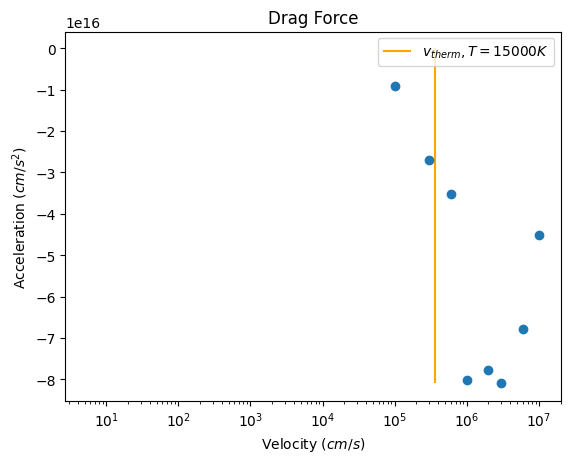

In [18]:
meanaccel=np.zeros(numfiles)
stdaccel=np.zeros(numfiles)

for i in range(numfiles):
    meanaccel[i] = bestfits[i,0] #divide by mass to get acceleration
    stdaccel[i] = bestfits[i,3]
print(meanaccel)
plt.figure()
plt.title("Drag Force")
plt.errorbar(velarr,meanaccel,yerr=stdaccel,fmt="o")
plt.xscale("log")
plt.vlines(x=thermvel,ymin=np.min(meanaccel),ymax=0,color="orange",label=r"$v_{{therm}},T={}K$".format(Temp))
plt.legend()
plt.xlabel(r"Velocity ($cm/s$)")
plt.ylabel(r"Acceleration ($cm/s^2$)")
plt.show()


In [21]:
np.save(folder+"/mean.npy",meanaccel)
np.save(folder+"/std.npy",stdaccel)
np.save(folder+"/vel.npy",velarr)

# Fits